In [ ]:
# Write a util function called merge_celltypes that does the 0.2 filtration and maxes them into one giant adata object with however many spots
# And then see if COMMOT can handle it.

In [1]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [5]:
import scanpy as sc
import squidpy as sq
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing

import scanpy as sc
from model.utils import plot_neighbors_with_fixed_radius


cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


# Load dataset
path_to_visium_folder ="/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS23-10650/outs"
adata = sq.read.visium(path_to_visium_folder, counts_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

# Initialize the model
model = CitegeistModel(sample_name="MWS23-10650", adata=adata, output_folder='output')

# Load cell profile dictionary
model.load_cell_profile_dict(cell_profiles)

# Preprocess and run models
# Split into gene expression and antibody capture datasets
model.split_adata()

model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

model.copy_gex_to_protein_adata()
# Preprocess datasets
model.preprocess_gex()
model.preprocess_antibody()

# Plot cell proportions (Append cell proportions) 
model.append_proportions_to_adata(key='finetuned')

# Plot cell proportions (Append cell proportions) 
model.append_gex_to_adata(pass_number=1)

prop_gex_adata = model.get_adata()

print(prop_gex_adata)

/bgfs/alee/LO_LAB/Personal/Alexander_Chang/alc376/envs/COMMOT/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


CitegeistModel initialized successfully.
AnnData has been successfully split into 'gene_expression_adata' and 'antibody_capture_adata'.
Filtered gene expression data: 18085 → 10029 genes (count > 0 in at least 1.0% of spots, mean expression > 1.1 in nonzero spots). Remaining spots: 4853 Filtered spots: 4992 to 4853
Antibody capture data preprocessing completed: Winsorized, CLR applied, no NaNs detected.

Before sorting:
CSV spots 1-10: ['AACACCTACTATCGAA-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACAGTCGTGTCGCGG-1']
AnnData spots 1-10: ['AACACCTACTATCGAA-1', 'AACACTTGGCAAGGAA-1', 'AACAGGAAGAGCATAG-1', 'AACAGGATTCATAGTT-1', 'AACAGGCCAACGATTA-1', 'AACAGGTTATTGCACC-1', 'AACAGGTTCACCGAAG-1', 'AACAGTCAGGCTCCGC-1', 'AACAGTCCACGCGGTG-1', 'AACAGTCGTGTCGCGG-1']
✅ Cell type proportions have been appended to adata.obs and results['cell_prop']
Parquet file for 

In [15]:
import commot as ct
import scanpy as sc
import pandas as pd
import numpy as np

In [28]:
import importlib
import model
importlib.reload(model.analysis_functions)
from model.analysis_functions import filter_spots_by_celltype_proportion, expand_prop_gex_adata

expanded_adata = expand_prop_gex_adata(prop_gex_adata, celltype_profile_dict=cell_profiles)
print(expanded_adata)

AnnData object with n_obs × n_vars = 7362 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'CD4_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Macrophages_genes_pass1'


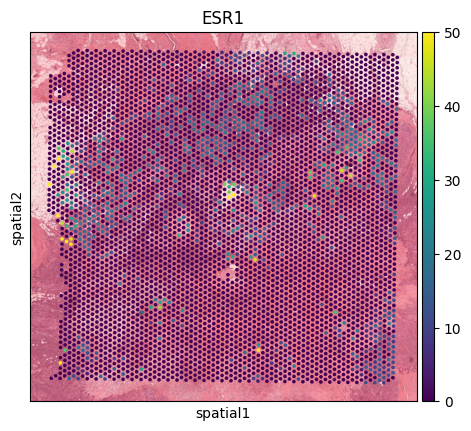

In [47]:
sc.pl.spatial(prop_gex_adata, layer="Cancer_Cells_genes_pass1", color='ESR1', vmax = 50)

In [40]:
df_ligrec=ct.pp.ligand_receptor_database(database='CellChat', species='human')

df_cellchat_filtered = ct.pp.filter_lr_database(df_ligrec, prop_gex_adata, min_cell_pct=0.01)

print(df_cellchat_filtered)

          0                    1         2                   3
0     TGFB3        TGFBR1_TGFBR2      TGFb  Secreted Signaling
1     TGFB3        ACVR1B_TGFBR2      TGFb  Secreted Signaling
2     TGFB3  ACVR1_TGFBR1_TGFBR2      TGFb  Secreted Signaling
3     GDF11        TGFBR1_ACVR2A       GDF  Secreted Signaling
4     GDF11        TGFBR1_ACVR2B       GDF  Secreted Signaling
..      ...                  ...       ...                 ...
100    GAS6                  AXL       GAS  Secreted Signaling
101    GAS6                MERTK       GAS  Secreted Signaling
102     GRN                SORT1       GRN  Secreted Signaling
103  LGALS9               HAVCR2  GALECTIN  Secreted Signaling
104  LGALS9                 CD44  GALECTIN  Secreted Signaling

[105 rows x 4 columns]


In [49]:
ct.tl.spatial_communication(prop_gex_adata, database_name='cellchat', df_ligrec=df_cellchat_filtered, dis_thr=100, heteromeric=True, pathway_sum=True)

In [50]:
print(prop_gex_adata)

AnnData object with n_obs × n_vars = 4853 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'commot-cellchat-info'
    obsm: 'spatial', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver'
    layers: 'CD4_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Endothelial_Cells_genes_pass1', 'B_Cells_genes_pass1', 'Macrophages_genes_pass1'
    obsp: 'commot-cellchat-CCL17-ACKR1', 'commot-cellchat-MIF-CD74_CD44', 'commot-cellchat-MIF-CD74_CXCR4', 'commot-cellchat-CCL8-ACKR1', 'commot-cellchat-ANGPTL2-ITGA5_ITGB1', 'commot-cellchat-MSTN-ACVR1B_ACVR2A', 'commot-cellchat-MSTN-TGFBR1_ACVR2A', 'commot-cellchat-MSTN-A

In [43]:
sender_signal = prop_gex_adata.obsm['commot-cellchat-sum-sender']
reciever_signal = prop_gex_adata.obsm['commot-cellchat-sum-receiver']


In [46]:
# Calculate the mean of each column
means = reciever_signal.mean()
print(means)

# Filter columns with non-zero means
nonzero_means = means[means != 0]

# Sort columns by mean values in descending order
sorted_means = nonzero_means.sort_values(ascending=False)

sorted_means.head(20)

r-CCL17-ACKR1            0.0
r-MIF-CD74_CD44          0.0
r-MIF-CD74_CXCR4         0.0
r-CCL8-ACKR1             0.0
r-ANGPTL2-ITGA5_ITGB1    0.0
                        ... 
r-TRAIL                  0.0
r-TWEAK                  0.0
r-VEGF                   0.0
r-VISFATIN               0.0
r-WNT                    0.0
Length: 133, dtype: float64


Series([], dtype: float64)

In [ ]:
pathway = 'CXCL12-CXCR4'

if f's-{pathway}' in adata_0.obsm['commot-cellchat-sum-sender'].columns:
    adata_0.obs[f's-{pathway}'] = adata_0.obsm['commot-cellchat-sum-sender'][f's-{pathway}']
    adata_0.obs[f'r-{pathway}'] = adata_0.obsm['commot-cellchat-sum-receiver'][f'r-{pathway}']
else:
    adata_0.obs[f's-{pathway}'] = np.zeros(adata_0.n_obs)
    adata_0.obs[f'r-{pathway}'] = np.zeros(adata_0.n_obs)
sc.pl.spatial(adata_0, color=[f's-{pathway}',f'r-{pathway}'], wspace = 0, vmin = 0, vmax = 0.2)